In [6]:
import sys

print(sys.executable)
print(sys.version)

/home/tuobawen/miniconda3/envs/mini-perturbseq/bin/python
3.11.15 | packaged by conda-forge | (main, Jun 11 2026, 03:34:02) [GCC 14.3.0]


In [7]:
import scanpy as sc
import pertpy as pt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
from pathlib import Path

current_directory = Path.cwd().resolve()
project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)
local_dataset_path = project_root / "notebooks" / "data" / "norman_2019.h5ad"

if local_dataset_path.exists():
    print(f"Loading cached dataset from {local_dataset_path}")
    adata = sc.read_h5ad(local_dataset_path)
else:
    print("Local dataset not found; PertPy will download and cache it.")
    adata = pt.data.norman_2019()

Loading cached dataset from /mnt/c/Users/Mike/Documents/GitHub/mini-perturbseq/notebooks/data/norman_2019.h5ad


In [9]:
adata

AnnData object with n_obs × n_vars = 111255 × 19018
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_AHR', 'guide_ARID1A', 'guide_ARRDC3', 'guide_ATL1', 'guide_BAK1', 'guide_BCL2L11', 'guide_BCORL1', 'guide_BPGM', 'guide_C19orf26', 'guide_C3orf72', 'guide_CBFA2T3', 'guide_CBL', 'guide_CDKN1A', 'guide_CDKN1B', 'guide_CDKN1C', 'guide_CEBPA', 'guide_CEBPB', 'guide_CEBPE', 'guide_CELF2', 'guide_CITED1', 'guide_CKS1B', 'guide_CLDN6', 'guide_CNN1', 'guide_CNNM4', 'guide_COL1A1', 'guide_COL2A1', 'guide_CSRNP1', 'guide_DLX2', 'guide_DUSP9', 'guide_EGR1', 'guide_ELMSAN1', 'guide_ETS2', 'guide_FEV', 'guide_FOSB', 'guide_FOXA1', 'guide_FOXA3', 'guide_FOXF1', 'guide_FOXL2', 'guide_FOXO4', 'guide_GLB1L2', 'guide_HES7', 'guide_HK2', 'guide_HNF4A', 'guide_HOXA13', 'guide_HOXB9', 'guide_HOXC13', 'guide_IER5L', 'guide_IGDCC3', 'guide_IKZF3', 'guide_IRF1', 'guide_ISL2', 'guide_JUN', 'guide_KIAA1804', 'guide_KIF18B', 'guide_KIF2C', '

In [10]:
adata.obs.head()

,guide_identity,read_count,UMI_count,coverage,gemgroup,good_coverage,number_of_cells,guide_AHR,guide_ARID1A,guide_ARRDC3,...,n_genes,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,leiden,perturbation_name,perturbation_type,perturbation_value,perturbation_unit
index,,,,,,,,,,,,,,,,,,,,,
AAACCTGAGAAGAAGC-1,NegCtrl0_NegCtrl0__NegCtrl0_NegCtrl0,1252,67,18.686567,1,True,2,0,0,0,...,4108,4108,19413.0,1327.0,6.835625,10,control,genetic,NaN,NaN
AAACCTGAGGCATGTG-1,TSC22D1_NegCtrl0__TSC22D1_NegCtrl0,2151,104,20.682692,1,True,1,0,0,0,...,3142,3142,13474.0,962.0,7.139676,3,TSC22D1,genetic,NaN,NaN
AAACCTGAGGCCCTTG-1,KLF1_MAP2K6__KLF1_MAP2K6,1037,59,17.576271,1,True,1,0,0,0,...,4229,4229,23228.0,1548.0,6.664371,7,KLF1+MAP2K6,genetic,NaN,NaN
AAACCTGCACGAAGCA-1,NegCtrl10_NegCtrl0__NegCtrl10_NegCtrl0,958,39,24.564103,1,True,1,0,0,0,...,2114,2114,6842.0,523.0,7.643963,2,control,genetic,NaN,NaN
AAACCTGCAGACGTAG-1,CEBPE_RUNX1T1__CEBPE_RUNX1T1,244,14,17.428571,1,True,1,0,0,0,...,2753,2753,9130.0,893.0,9.780942,10,CEBPE+RUNX1T1,genetic,NaN,NaN


In [11]:
adata.obs.columns.tolist()

['guide_identity',
 'read_count',
 'UMI_count',
 'coverage',
 'gemgroup',
 'good_coverage',
 'number_of_cells',
 'guide_AHR',
 'guide_ARID1A',
 'guide_ARRDC3',
 'guide_ATL1',
 'guide_BAK1',
 'guide_BCL2L11',
 'guide_BCORL1',
 'guide_BPGM',
 'guide_C19orf26',
 'guide_C3orf72',
 'guide_CBFA2T3',
 'guide_CBL',
 'guide_CDKN1A',
 'guide_CDKN1B',
 'guide_CDKN1C',
 'guide_CEBPA',
 'guide_CEBPB',
 'guide_CEBPE',
 'guide_CELF2',
 'guide_CITED1',
 'guide_CKS1B',
 'guide_CLDN6',
 'guide_CNN1',
 'guide_CNNM4',
 'guide_COL1A1',
 'guide_COL2A1',
 'guide_CSRNP1',
 'guide_DLX2',
 'guide_DUSP9',
 'guide_EGR1',
 'guide_ELMSAN1',
 'guide_ETS2',
 'guide_FEV',
 'guide_FOSB',
 'guide_FOXA1',
 'guide_FOXA3',
 'guide_FOXF1',
 'guide_FOXL2',
 'guide_FOXO4',
 'guide_GLB1L2',
 'guide_HES7',
 'guide_HK2',
 'guide_HNF4A',
 'guide_HOXA13',
 'guide_HOXB9',
 'guide_HOXC13',
 'guide_IER5L',
 'guide_IGDCC3',
 'guide_IKZF3',
 'guide_IRF1',
 'guide_ISL2',
 'guide_JUN',
 'guide_KIAA1804',
 'guide_KIF18B',
 'guide_KIF2C',


## Perturbation composition

We first examine the perturbation assignments to understand the
experimental structure of the Perturb-seq dataset.

In [12]:
adata.obs["perturbation_name"].value_counts()

perturbation_name
control          11835
KLF1              1954
BAK1              1451
CEBPE             1230
CEBPE+RUNX1T1     1215
                 ...  
CEBPA+CEBPB         64
CBL+UBASH3A         64
C3orf72+FOXL2       59
CEBPB+JUN           59
CEBPA+JUN           54
Name: count, Length: 237, dtype: int64

In [13]:
adata.obs["guide_identity"].nunique()

290

In [14]:
adata.obs["perturbation_name"].nunique()

237

### Classifying perturbation types

The dataset contains negative controls, single-gene perturbations,
and combinatorial perturbations. For the initial analysis, I classify
cells into these three groups based on `perturbation_name`.

Single-gene perturbations will be used for the first differential
expression analysis to keep the interpretation simple.

In [15]:
perturbations = adata.obs["perturbation_name"]

n_control = (perturbations == "control").sum()
n_single = (
    (perturbations != "control") &
    ~perturbations.str.contains(r"\+")
).sum()

n_double = perturbations.str.contains(r"\+").sum()

print("Control cells:", n_control)
print("Single-perturbation cells:", n_single)
print("Double-perturbation cells:", n_double)

Control cells: 11835
Single-perturbation cells: 57735
Double-perturbation cells: 41685


In [16]:
def classify_perturbation(name):
    if name == "control":
        return "control"
    elif "+" in name:
        return "double"
    else:
        return "single"

adata.obs["perturbation_class"] = (
    adata.obs["perturbation_name"]
    .astype(str)
    .apply(classify_perturbation)
)

In [17]:
adata.obs[
    ["guide_identity", "perturbation_name", "perturbation_class"]
].head(10)

,guide_identity,perturbation_name,perturbation_class
index,,,
AAACCTGAGAAGAAGC-1,NegCtrl0_NegCtrl0__NegCtrl0_NegCtrl0,control,control
AAACCTGAGGCATGTG-1,TSC22D1_NegCtrl0__TSC22D1_NegCtrl0,TSC22D1,single
AAACCTGAGGCCCTTG-1,KLF1_MAP2K6__KLF1_MAP2K6,KLF1+MAP2K6,double
AAACCTGCACGAAGCA-1,NegCtrl10_NegCtrl0__NegCtrl10_NegCtrl0,control,control
AAACCTGCAGACGTAG-1,CEBPE_RUNX1T1__CEBPE_RUNX1T1,CEBPE+RUNX1T1,double
AAACCTGCAGCCTTGG-1,MAML2_NegCtrl0__MAML2_NegCtrl0,MAML2,single
AAACCTGCATCTCCCA-1,NegCtrl0_CEBPE__NegCtrl0_CEBPE,CEBPE,single
AAACCTGCATTACCTT-1,ETS2_MAP7D1__ETS2_MAP7D1,ETS2+MAP7D1,double
AAACCTGGTATAATGG-1,NegCtrl0_NegCtrl0__NegCtrl0_NegCtrl0,control,control


In [18]:
adata.obs["perturbation_class"].value_counts()

perturbation_class
single     57735
double     41685
control    11835
Name: count, dtype: int64

In [19]:
single_mask = adata.obs["perturbation_class"] == "single"

single_counts = (
    adata.obs.loc[single_mask, "perturbation_name"]
    .value_counts()
)

single_counts.head(20)

perturbation_name
KLF1        1954
BAK1        1451
CEBPE       1230
UBASH3B     1201
ETS2        1201
OSR2        1002
SLC4A1       998
SET          985
ELMSAN1      935
MAP2K6       878
FOXF1        873
C19orf26     872
FOXA1        850
UBASH3A      817
RUNX1T1      777
MEIS1        775
CNN1         765
MAPK1        763
MAP7D1       751
ZBTB25       739
Name: count, dtype: int64

In [20]:
print("Total cells:", adata.n_obs)
print("Genes:", adata.n_vars)

print("\nPerturbation classes:")
print(adata.obs["perturbation_class"].value_counts())

print("\nUnique perturbations:",
      adata.obs["perturbation_name"].nunique())

print("Unique single perturbations:",
      adata.obs.loc[single_mask, "perturbation_name"].nunique())

Total cells: 111255
Genes: 19018

Perturbation classes:
perturbation_class
single     57735
double     41685
control    11835
Name: count, dtype: int64

Unique perturbations: 237
Unique single perturbations: 105


### Dataset summary

The dataset contains 111,255 cells and 19,018 genes.

Most cells belong to single-gene perturbations, while a substantial
fraction contain combinatorial perturbations. For the first analysis,
I will focus on a small set of well-represented single-gene
perturbations together with negative-control cells.

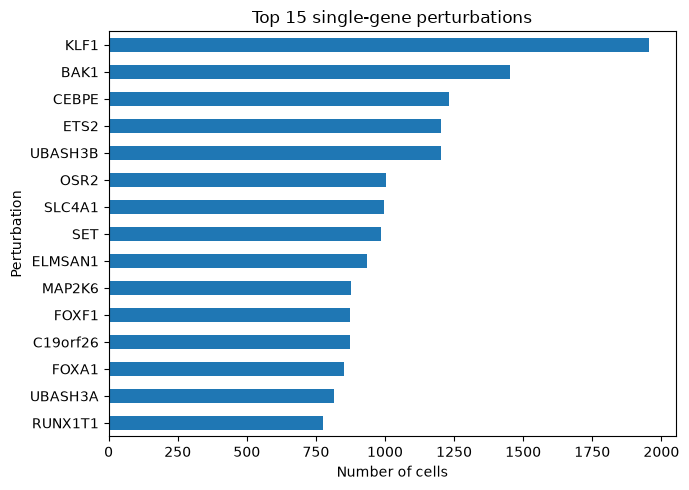

In [21]:
top15 = single_counts.head(15)

ax = top15.sort_values().plot(
    kind="barh",
    figsize=(7, 5)
)

ax.set_xlabel("Number of cells")
ax.set_ylabel("Perturbation")
ax.set_title("Top 15 single-gene perturbations")

plt.tight_layout()
plt.show()

In [22]:
selected_perturbations = [
    "KLF1",
    "BAK1",
    "CEBPE",
    "ETS2",
    "MAP2K6",
]

In [23]:
keep = (
    adata.obs["perturbation_name"].isin(selected_perturbations)
    | (adata.obs["perturbation_name"] == "control")
)

adata_sub = adata[keep].copy()

adata_sub

AnnData object with n_obs × n_vars = 18549 × 19018
    obs: 'guide_identity', 'read_count', 'UMI_count', 'coverage', 'gemgroup', 'good_coverage', 'number_of_cells', 'guide_AHR', 'guide_ARID1A', 'guide_ARRDC3', 'guide_ATL1', 'guide_BAK1', 'guide_BCL2L11', 'guide_BCORL1', 'guide_BPGM', 'guide_C19orf26', 'guide_C3orf72', 'guide_CBFA2T3', 'guide_CBL', 'guide_CDKN1A', 'guide_CDKN1B', 'guide_CDKN1C', 'guide_CEBPA', 'guide_CEBPB', 'guide_CEBPE', 'guide_CELF2', 'guide_CITED1', 'guide_CKS1B', 'guide_CLDN6', 'guide_CNN1', 'guide_CNNM4', 'guide_COL1A1', 'guide_COL2A1', 'guide_CSRNP1', 'guide_DLX2', 'guide_DUSP9', 'guide_EGR1', 'guide_ELMSAN1', 'guide_ETS2', 'guide_FEV', 'guide_FOSB', 'guide_FOXA1', 'guide_FOXA3', 'guide_FOXF1', 'guide_FOXL2', 'guide_FOXO4', 'guide_GLB1L2', 'guide_HES7', 'guide_HK2', 'guide_HNF4A', 'guide_HOXA13', 'guide_HOXB9', 'guide_HOXC13', 'guide_IER5L', 'guide_IGDCC3', 'guide_IKZF3', 'guide_IRF1', 'guide_ISL2', 'guide_JUN', 'guide_KIAA1804', 'guide_KIF18B', 'guide_KIF2C', 'g

In [24]:
adata_sub.obs["perturbation_name"].value_counts()

perturbation_name
control    11835
KLF1        1954
BAK1        1451
CEBPE       1230
ETS2        1201
MAP2K6       878
Name: count, dtype: int64

## Save the working subset

The full Norman dataset is large and slow to load. We therefore save the control cells and five selected perturbations as a reusable intermediate file. The file is written to the repository's top-level `data/` directory, which is ignored by Git because it can be regenerated from this notebook.

Downstream notebooks load this smaller subset directly. If the selected perturbations or upstream preparation change, rerun this notebook to regenerate the cached file.

In [25]:
from pathlib import Path

current_directory = Path.cwd().resolve()
project_root = (
    current_directory.parent
    if current_directory.name == "notebooks"
    else current_directory
)

if not (project_root / "notebooks").is_dir():
    raise RuntimeError(
        "Could not locate the project root. Start Jupyter from the repository "
        "root or its notebooks directory."
    )

data_directory = project_root / "data"
data_directory.mkdir(parents=True, exist_ok=True)
subset_path = data_directory / "norman_2019_selected.h5ad"

adata_sub.write_h5ad(subset_path)

print(f"Saved {adata_sub.n_obs:,} cells and {adata_sub.n_vars:,} genes")
print(f"Subset path: {subset_path}")
print(f"File size: {subset_path.stat().st_size / 1e9:.2f} GB")

Saved 18,549 cells and 19,018 genes
Subset path: /mnt/c/Users/Mike/Documents/GitHub/mini-perturbseq/data/norman_2019_selected.h5ad
File size: 1.06 GB
